🚀 BẮT ĐẦU MÔ PHỎNG REACTIVE AUTOSCALING TRÊN TẬP TEST (PHẦN V.A)...
-> Đã đọc file 'worldcup_workload.csv' thành công.
-> Chạy mô phỏng trên toàn bộ thời lượng: 87 phút.
Đã lưu

 📊 BẢNG TỔNG KẾT CHỈ SỐ (TABLE I METRICS - REACTIVE TỪ PHÚT 10)
 Tổng số phút kiểm thử          : 77 phút
 Tổng request đầu vào (Input)   : 8,032,318 requests
 Total Processed Requests       : 2,785,238 requests
 Total SLO Violations           : 5,247,080 requests
 SLO Violation (%)              : 65.32%
 Processed Requests (%)         : 34.68%

✅ Đã xuất biểu đồ ra file '../data/worldcup_reactive.png'!


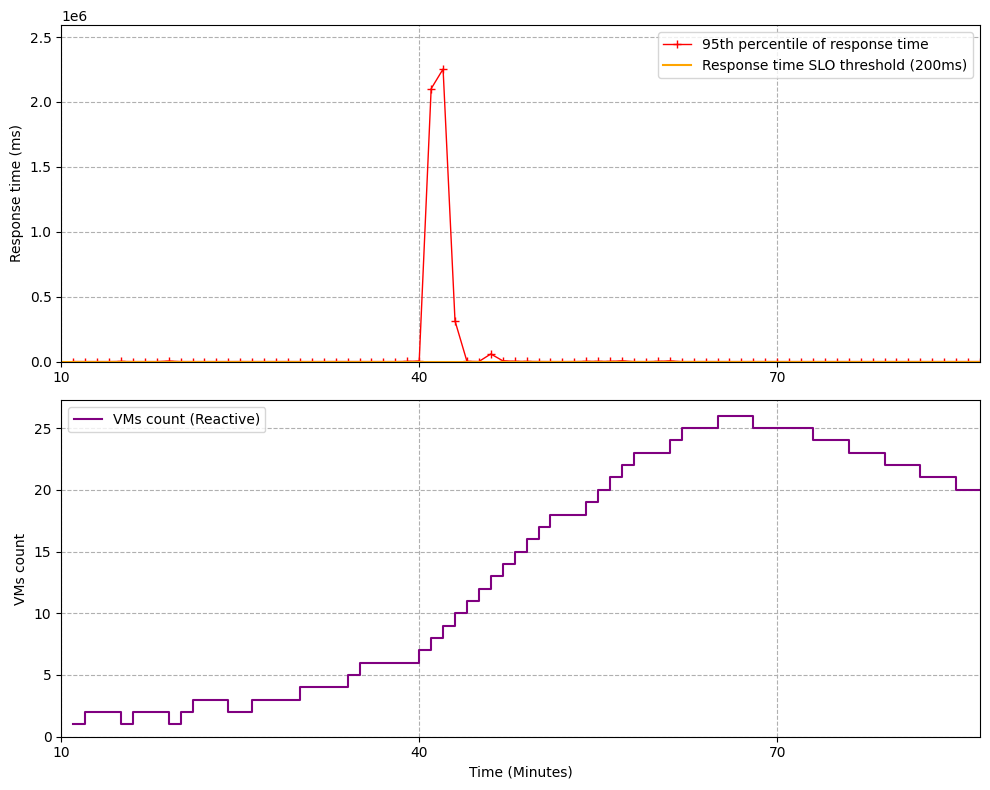

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("🚀 BẮT ĐẦU MÔ PHỎNG REACTIVE AUTOSCALING TRÊN TẬP TEST (PHẦN V.A)...")

# --- 1. CẤU HÌNH THAM SỐ HỆ THỐNG ---
A_PARAM = 8.24018 
B_PARAM = -0.0003632
C_PARAM = -47.27967 

TAU_SLO = 200            # Ngưỡng SLO (ms)
SCALE_IN_LIMIT = 100     # tau_slo / 2[cite: 1, 2]
K_BEST = 10              # Mốc cửa sổ trễ để đồng bộ vẽ biểu đồ


def get_response_time(total_requests, num_vms):
    """Mô phỏng RT dựa trên mô hình hàm mũ """
    n_t = total_requests / num_vms
    rt = A_PARAM * np.exp(-B_PARAM * n_t) + C_PARAM
    # Thêm nhiễu trắng mô phỏng biến động thực tế [cite: 13]
    # noise = np.random.normal(0, 5) 
    # return max(10, rt + noise)
    return max(10, rt)

# --- 2. ĐỌC FILE DỮ LIỆU GỐC VÀ CHIA 80/20 ĐÚNG CHUẨN ---
try:
    original_df = pd.read_csv('../../workload_generation_and_forecasting/workload_generation/data/worldcup_workload.csv')
    print("-> Đã đọc file 'worldcup_workload.csv' thành công.")
except FileNotFoundError:
    print("❌ Lỗi: Không tìm thấy file dữ liệu. Vui lòng kiểm tra lại đường dẫn!")
    original_df = None

# Kiểm tra nếu đọc được file thì mới chạy tiếp
if original_df is not None:
    # Lấy toàn bộ chuỗi request và thời gian từ file gốc
    test_requests = original_df['requests'].values
    test_times = original_df['time'].values
    test_duration = len(test_requests)

    print(f"-> Chạy mô phỏng trên toàn bộ thời lượng: {test_duration} phút.")

    # --- 3. MÔ PHỎNG ALGORITHM 1 (REACTIVE AUTOSCALING) TRÊN TẬP TEST ---
    reactive_vms = 1
    reactive_logs = []
    scale_in_counter = 0

    for t in range(test_duration):
        w_t = test_requests[t]
        
        # Tính thời gian phản hồi thực tế ứng với lượng request và số VM hiện tại
        r_t = get_response_time(w_t, reactive_vms)
        
        reactive_logs.append({
            "minute": test_times[t],
            "requests": w_t,
            "response_time": r_t,
            "vms_count": reactive_vms
        })
        
        # Logic điều khiển Reactive (Algorithm 1)
        if r_t > TAU_SLO:
            reactive_vms += 1
            scale_in_counter = 0
        elif r_t < SCALE_IN_LIMIT:
            scale_in_counter += 1
            if scale_in_counter >= 3:
                if reactive_vms > 1:
                    reactive_vms -= 1
                scale_in_counter = 0
        else:
            scale_in_counter = 0

    df_reactive = pd.DataFrame(reactive_logs)

    df_reactive.to_csv("../reactive_autoscaling/data/worldcup_reactive.csv", index=False)
    print(f"Đã lưu")


# =========================================================
    # --- 4. TÍNH TOÁN CÁC CHỈ SỐ CHO TABLE I (ĐÃ ĐIỀU CHỈNH CHUẨN) ---
    # =========================================================
    # --- 3. TÍNH TOÁN CÁC CHỈ SỐ CHO TABLE I (TỪ PHÚT K TRỞ ĐI ĐỂ ĐỒNG BỘ VỚI PREDICTIVE) ---
    df_evaluation = df_reactive[df_reactive['minute'] > K_BEST]
    
    test_duration = len(df_evaluation)
    total_input_requests = df_evaluation['requests'].sum()
    
    df_violations = df_evaluation[df_evaluation['response_time'] > TAU_SLO]
    total_slo_violations_requests = df_violations['requests'].sum()
    
    total_processed_requests = total_input_requests - total_slo_violations_requests
    
    slo_violation_percentage = (total_slo_violations_requests / total_input_requests) * 100
    processed_requests_percentage = (total_processed_requests / total_input_requests) * 100

    print("\n" + "="*65)
    print(f" 📊 BẢNG TỔNG KẾT CHỈ SỐ (TABLE I METRICS - REACTIVE TỪ PHÚT {K_BEST})")
    print("="*65)
    print(f" Tổng số phút kiểm thử          : {test_duration} phút")
    print(f" Tổng request đầu vào (Input)   : {total_input_requests:,} requests")
    print(f" Total Processed Requests       : {total_processed_requests:,} requests")
    print(f" Total SLO Violations           : {total_slo_violations_requests:,} requests")
    print(f" SLO Violation (%)              : {slo_violation_percentage:.2f}%")
    print(f" Processed Requests (%)         : {processed_requests_percentage:.2f}%")
    print("="*65)

# --- 5. TỰ ĐỘNG TÍNH MAX RESPONSE TIME TỪ PHÚT K TRỞ ĐI CHO ĐỒ THỊ ---
    max_rt_after_k = df_evaluation['response_time'].max()
    # Giới hạn trên trục Y sẽ lấy max thực tế nhân thêm khoảng 15% cho thoáng, nhưng phải đảm bảo ít nhất cao hơn đường ngưỡng SLO
    y_upper_limit = max(max_rt_after_k * 1.15, TAU_SLO * 1.25)

    # --- 6. VẼ BIỂU ĐỒ TRỰC QUAN ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False)
    max_minute = df_reactive['minute'].max()

    ticks = np.arange(K_BEST, max_minute + 1, 30)

    # 1. Đồ thị Response Time (Phía trên) với trục Y co giãn theo max thực tế phía sau K
    ax1.plot(df_evaluation['minute'], df_evaluation['response_time'], color='red', marker='+', label='95th percentile of response time', linewidth=1)
    ax1.axhline(y=TAU_SLO, color='orange', linestyle='-', label='Response time SLO threshold (200ms)')
    ax1.set_ylabel('Response time (ms)')
    ax1.legend()
    ax1.grid(True, linestyle='--')

    ax1.set_xlim(left=K_BEST, right=max_minute)
    ax1.set_xticks(ticks)
    ax1.set_ylim(bottom=0, top=y_upper_limit)  # 🌟 Co giãn tự động theo max phía sau K

    # 2. Đồ thị VMs count (Phía dưới)
    ax2.step(df_evaluation['minute'], df_evaluation['vms_count'], color='purple', where='post', label='VMs count (Reactive)')
    ax2.set_ylabel('VMs count')
    ax2.set_xlabel('Time (Minutes)')
    ax2.legend()
    ax2.grid(True, linestyle='--')

    ax2.set_xlim(left=K_BEST, right=max_minute)
    ax2.set_xticks(ticks)
    ax2.set_ylim(bottom=0)

    plt.tight_layout()
    plt.savefig("../reactive_autoscaling/data/worldcup_reactive.png", dpi=300)
    print("\n✅ Đã xuất biểu đồ ra file '../data/worldcup_reactive.png'!")
    plt.show()